# Gaussian Shading vs. Percentile Rotation vs. Threshold Skipping

A self-contained latent-space experiment comparing three watermark decoding rules under
controlled synthetic perturbations.

## 1. Experimental Question

Given the same underlying Gaussian latent $z$ and the same inversion error $\epsilon$, which decoding
rule is more robust: **sign-based (Gaussian Shading-style)** decoding, **percentile-rotation** decoding,
or **Bindschaedler-style threshold decoding** that skips low-magnitude coordinates?

**This is not a diffusion experiment.** There is no encoding step, because none is mathematically
needed. We draw the latent, perturb it, and apply the decision rules to the result:

$$z \sim N(0,1) \quad\rightarrow\quad \hat z = z + \epsilon \quad\rightarrow\quad \text{decode}$$

The purpose is to isolate the effect of the latent-space decoding geometry. Later, empirical diffusion
inversion errors can be substituted for the synthetic error models. Nothing here establishes how any
scheme behaves on real diffusion models; all results describe *performance under specified synthetic
latent-space error channels*.

## 2. Mathematical Setup

**Latent and perturbation.** For $i = 1,\dots,N$: $z_i \sim N(0,1)$, $\hat z_i = z_i + \epsilon_i$. Every
decoder sees the identical $z_i$ and $\epsilon_i$ — a matched-pairs design. The base array $z$ is drawn
once and reused across every error distribution and every $\sigma$; only $\epsilon$ is redrawn.

**Gaussian Shading (sign rule).** The bit is $b_i = \mathbf 1[z_i \ge 0]$, decoded as
$\hat b_i = \mathbf 1[\hat z_i \ge 0]$; an error is a sign flip.

**Percentile rotation.** With $\Phi$ the standard normal CDF and a shift $\alpha_{\text{rot}} = 0.5$,

$$T(z) = \Phi^{-1}\!\left( (\Phi(z) + \alpha_{\text{rot}}) \bmod 1 \right).$$

The hypotheses are $H_0 = z_i$ and $H_1 = T(z_i)$, and decoding picks the nearer one in latent space:
$|\hat z_i - z_i|$ vs. $|\hat z_i - T(z_i)|$. Since the rotation is never actually applied, the true bit
is $0$ everywhere and this decoder errs exactly when $\hat z_i$ lands closer to $T(z_i)$.

**Bindschaedler-style threshold decoding.** With a threshold $\alpha_{\text{thr}} > 0$, a coordinate is
*skipped* if $|z_i| < \alpha_{\text{thr}}$ and *encoded* otherwise. Encoded coordinates are decoded by
sign, so a coordinate is erroneous iff $|z_i| \ge \alpha_{\text{thr}}$ **and** the sign flips. Skipped
coordinates are not errors and are excluded from the denominator:

$$\text{BER}_{\text{thr}} = \frac{\#\{|z| \ge \alpha_{\text{thr}} \text{ and sign error}\}}{\#\{|z| \ge \alpha_{\text{thr}}\}},$$

reported as NaN when nothing is encoded. Skip status is determined from the **pre-noise** latent $z$.
That is deliberate: this synthetic experiment isolates the robustness of the thresholding rule, not the
information flow of a real system, so we never try to infer skip status from $\hat z$.

**Metric.** BER against the error standard deviation $\sigma$, with all five error distributions
standardised to that same $\sigma$. Note the denominators differ: the sign and rotation rules are scored
over all $N$ coordinates, the threshold rule only over the encoded subset.

## 3. Imports and Configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

SEED = 42
rng = np.random.default_rng(SEED)   # single generator used for every random draw

N = 100_000                         # coordinates per trial
SIGMAS = np.linspace(0.0, 2.0, 15)  # error std devs on the x-axis of the main plots
ROT_ALPHA = 0.5                     # percentile shift of the rotation transform
THR_ALPHA = 0.5                     # |z| below this is skipped by the threshold decoder

T_DF = 3                            # Student-t degrees of freedom
MIX_P = 0.05                        # mixture: probability of the heavy component
MIX_R1 = 1.0                        # mixture: std-dev ratio of the light component
MIX_R2 = 10.0                       # mixture: std-dev ratio of the heavy component

PPF_EPS = 1e-12                     # clip for the argument of norm.ppf (see Section 4)

# The base latent is drawn ONCE and reused for every (distribution, sigma) condition, so the
# design is paired across decoders and across noise conditions.
z = rng.standard_normal(N)

RESULTS_DIR = Path("results")
FIG_DIR = RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DIST_NAMES = ["gaussian", "laplace", "student_t", "mixture", "uniform"]
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

print(f"N = {N}, seed = {SEED}, z: mean {z.mean():.4f}, std {z.std():.4f}")

N = 100000, seed = 42, z: mean -0.0042, std 1.0037


## 4. Core Functions

**Rotation transform.** $(\Phi(z) + 0.5) \bmod 1$ approaches $0$ or $1$ as $\Phi(z) \to 0.5$, i.e. as
$z \to 0$ — the *median*, where sample density is highest, not the tails. The argument of `norm.ppf` is
therefore clipped to $[\varepsilon, 1-\varepsilon]$ with $\varepsilon = 10^{-12}$ so floating-point edge
cases cannot produce $\pm\infty$.

**Error models**, all standardised to variance $\sigma^2$:

- **Gaussian:** $\epsilon \sim N(0, \sigma^2)$.
- **Laplace:** variance is $2b^2$, so $b = \sigma/\sqrt2$.
- **Student-t** with $\nu = 3$: a *raw* $t_\nu$ variable has variance $\nu/(\nu-2)$, not $1$, so passing
  `scale=sigma` would silently inflate it. The correct rescaling is
  $\epsilon = t_{\text{raw}}\,\sigma\sqrt{(\nu-2)/\nu}$, i.e. $t_{\text{raw}}\,\sigma/\sqrt3$ at
  $\nu = 3$ — a heavy-tailed case that still has finite variance.
- **Gaussian mixture:** with $\sigma_1 = r_1 u$, $\sigma_2 = r_2 u$, the variance is
  $u^2[(1-p)r_1^2 + p r_2^2]$, so $u = \sigma/\sqrt{(1-p)r_1^2 + p r_2^2}$ gives exactly $\sigma^2$.
- **Uniform** on $[-a,a]$: variance is $a^2/3$, so $a = \sqrt3\,\sigma$.

In [2]:
def rotate_latent(z, alpha=ROT_ALPHA):
    # T(z) = Phi^-1((Phi(z) + alpha) mod 1). The mod wraps to 0/1 as z -> 0 (Phi(z) -> 0.5),
    # so clipping is what keeps ppf finite at the median.
    u = (stats.norm.cdf(z) + alpha) % 1.0
    return stats.norm.ppf(np.clip(u, PPF_EPS, 1.0 - PPF_EPS))


def generate_error(dist, sigma, size, rng):
    """Draw an error vector with standard deviation exactly `sigma` (in expectation)."""
    if dist == "gaussian":
        return rng.normal(0.0, sigma, size)
    if dist == "laplace":
        return rng.laplace(0.0, sigma / np.sqrt(2.0), size)  # Var = 2b^2
    if dist == "student_t":
        # random_state=rng is required: SciPy does not otherwise use our Generator.
        t_raw = stats.t.rvs(df=T_DF, size=size, random_state=rng)
        return t_raw * sigma * np.sqrt((T_DF - 2) / T_DF)    # raw Var = nu/(nu-2)
    if dist == "mixture":
        u = sigma / np.sqrt((1 - MIX_P) * MIX_R1**2 + MIX_P * MIX_R2**2)
        heavy = rng.random(size) < MIX_P
        scales = np.where(heavy, MIX_R2 * u, MIX_R1 * u)
        return rng.normal(0.0, 1.0, size) * scales
    if dist == "uniform":
        a = np.sqrt(3.0) * sigma                             # Var = a^2/3
        return rng.uniform(-a, a, size)
    raise ValueError(f"unknown distribution: {dist}")


# --- decoders: each returns an error mask (True = incorrect decoding) -------------------
# The true bit is 0 for every coordinate, since no rotation was ever applied.

def decode_gaussian_shading(z, z_hat):
    # Convention: z >= 0 is bit 0, so exact zeros count as non-negative. Written as an
    # explicit comparison rather than np.sign, whose value at 0 is neither +/-.
    return (z_hat >= 0) != (z >= 0)


def decode_rotation(z, z_hat, t_z=None):
    # Nearest hypothesis in latent space. Tie-break: exact ties decode as bit 0 (hence `>`).
    t_z = rotate_latent(z) if t_z is None else t_z
    return np.abs(z_hat - z) > np.abs(z_hat - t_z)


def decode_threshold(z, z_hat, alpha=THR_ALPHA):
    """Bindschaedler-style threshold/skip rule. Coordinates with |z| < alpha are skipped and
    can never be errors; the rest are decoded by sign. Skip status comes from the pre-noise
    z by design (see Section 2) - it is never inferred from z_hat. Boundary convention
    matches the spec: |z| == alpha is encoded, not skipped.
    Returns (encoded_mask, error_mask); error_mask is True only on encoded coordinates."""
    encoded = np.abs(z) >= alpha
    return encoded, encoded & decode_gaussian_shading(z, z_hat)


def threshold_stats(encoded, thr_err, n):
    n_encoded = int(encoded.sum())
    return {
        "thr_n_skipped": n - n_encoded,
        "thr_n_encoded": n_encoded,
        "thr_skip_rate": (n - n_encoded) / n,
        "thr_encoded_rate": n_encoded / n,
        # Denominator is the encoded subset only; NaN rather than 0 when nothing is encoded.
        "thr_ber": int(thr_err.sum()) / n_encoded if n_encoded else np.nan,
    }


def evaluate_condition(z, dist, sigma, rng, t_z=None):
    """One (distribution, sigma) condition: draw epsilon, decode with all three rules."""
    eps = generate_error(dist, sigma, z.size, rng)
    z_hat = z + eps
    gs_err = decode_gaussian_shading(z, z_hat)
    rot_err = decode_rotation(z, z_hat, t_z)
    encoded, thr_err = decode_threshold(z, z_hat)

    gs_ber, rot_ber = gs_err.mean(), rot_err.mean()
    row = {
        "distribution": dist, "sigma": sigma,
        "gs_errors": int(gs_err.sum()),
        "rot_errors": int(rot_err.sum()),
        "thr_errors": int(thr_err.sum()),
        "gs_ber": gs_ber, "rot_ber": rot_ber,
        "ber_diff": rot_ber - gs_ber,     # rotation BER - GS BER
        # Relative change is undefined when the GS BER is exactly 0 (common at small sigma).
        "rel_ber_change": (rot_ber - gs_ber) / gs_ber if gs_ber > 0 else np.nan,
        "both_correct": int(np.sum(~gs_err & ~rot_err)),
        "gs_only_correct": int(np.sum(~gs_err & rot_err)),
        "rot_only_correct": int(np.sum(gs_err & ~rot_err)),
        "both_wrong": int(np.sum(gs_err & rot_err)),
    }
    row.update(threshold_stats(encoded, thr_err, z.size))
    return row


# T(z) and the skip mask depend only on z, which is fixed, so compute them once.
T_z = rotate_latent(z)
ENCODED = np.abs(z) >= THR_ALPHA
assert np.all(np.isfinite(T_z)), "T(z) produced inf/nan"
print(f"T(z) finite everywhere; range [{T_z.min():.3f}, {T_z.max():.3f}]")
print(f"threshold alpha = {THR_ALPHA}: {ENCODED.sum()} encoded, {(~ENCODED).sum()} skipped "
      f"(skip rate {1 - ENCODED.mean():.4f}, expected {1 - 2 * stats.norm.cdf(-THR_ALPHA):.4f})")

T(z) finite everywhere; range [-4.057, 4.309]
threshold alpha = 0.5: 61569 encoded, 38431 skipped (skip rate 0.3843, expected 0.3829)


## 5. Zero-Noise Sanity Check

With $\epsilon = 0$ exactly, $\hat z = z$ and every decoder must recover every coordinate it scores.

In [3]:
z_hat0 = z + np.zeros(N)
zero_noise_errors = {
    "gaussian_shading": int(decode_gaussian_shading(z, z_hat0).sum()),
    "rotation": int(decode_rotation(z, z_hat0, T_z).sum()),
    "threshold": int(decode_threshold(z, z_hat0)[1].sum()),
}
assert sum(zero_noise_errors.values()) == 0, "zero-noise check failed - stop and investigate"
print("zero-noise errors:", zero_noise_errors, "-> all decoders exact")

zero-noise errors: {'gaussian_shading': 0, 'rotation': 0, 'threshold': 0} -> all decoders exact


## 6. Rotation Geometry

How far apart are the two rotation hypotheses? We look at $D(z) = |T(z) - z|$.

$D(z)$ *diverges* as $z \to 0$: at the median $\Phi(z) \approx 0.5$, so the shifted percentile wraps to
the extreme quantiles and $T(z)$ lands far away. This is the opposite of what intuition about "extreme
values" suggests, and it is why `norm.ppf` is clipped in Section 4.

The separation is not monotone, though. $D(z)$ is U-shaped in $|z|$: it falls from the spike at the
median to a minimum of $\approx 1.349$ at $|z| = 0.6745$ (the quartile, where the half-percentile shift
maps $z \mapsto -z$), then *grows again* in the tails, because $T(z) \to 0$ as $|z| \to \infty$ and so
$D(z) \to |z|$. The closest-together hypothesis pairs are the mid-range coordinates, not the extremes.

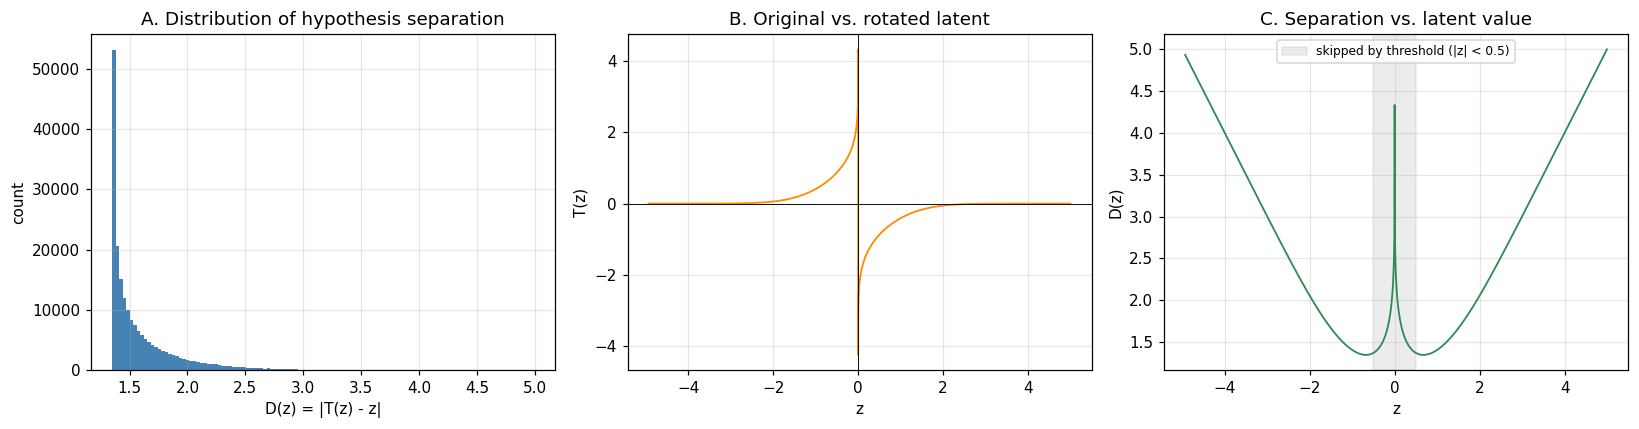

D(z): median 1.468, mean 1.595, max 4.993
  mean D(z) for 0.0 <= |z| < 0.05: 2.445
  mean D(z) for 0.6 <= |z| < 0.75: 1.350
  mean D(z) for 2.0 <= |z| < inf: 2.402


In [4]:
z_geom = rng.standard_normal(200_000)   # separate sample, geometry only
T_geom = rotate_latent(z_geom)
D_geom = np.abs(T_geom - z_geom)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(D_geom, bins=120, color="steelblue")
axes[0].set(xlabel="D(z) = |T(z) - z|", ylabel="count", title="A. Distribution of hypothesis separation")

order = np.argsort(z_geom)
axes[1].plot(z_geom[order], T_geom[order], lw=1.2, color="darkorange")
axes[1].axhline(0, color="k", lw=0.6); axes[1].axvline(0, color="k", lw=0.6)
axes[1].set(xlabel="z", ylabel="T(z)", title="B. Original vs. rotated latent")

axes[2].plot(z_geom[order], D_geom[order], lw=1.2, color="seagreen")
axes[2].axvspan(-THR_ALPHA, THR_ALPHA, color="grey", alpha=0.15, label=f"skipped by threshold (|z| < {THR_ALPHA})")
axes[2].legend(fontsize=8)
axes[2].set(xlabel="z", ylabel="D(z)", title="C. Separation vs. latent value")
fig.tight_layout()
fig.savefig(FIG_DIR / "rotation_geometry.png", bbox_inches="tight")
plt.show()

print(f"D(z): median {np.median(D_geom):.3f}, mean {D_geom.mean():.3f}, max {D_geom.max():.3f}")
for lo, hi in [(0.0, 0.05), (0.6, 0.75), (2.0, np.inf)]:
    m = (np.abs(z_geom) >= lo) & (np.abs(z_geom) < hi)
    print(f"  mean D(z) for {lo} <= |z| < {hi}: {D_geom[m].mean():.3f}")

## 7. Error Distributions

The five error models, all standardised to $\sigma = 1$ so their shapes are directly comparable.

empirical sd at sigma = 1: {'gaussian': 1.0004, 'laplace': 1.0012, 'student_t': 0.995, 'mixture': 0.996, 'uniform': 0.9984}


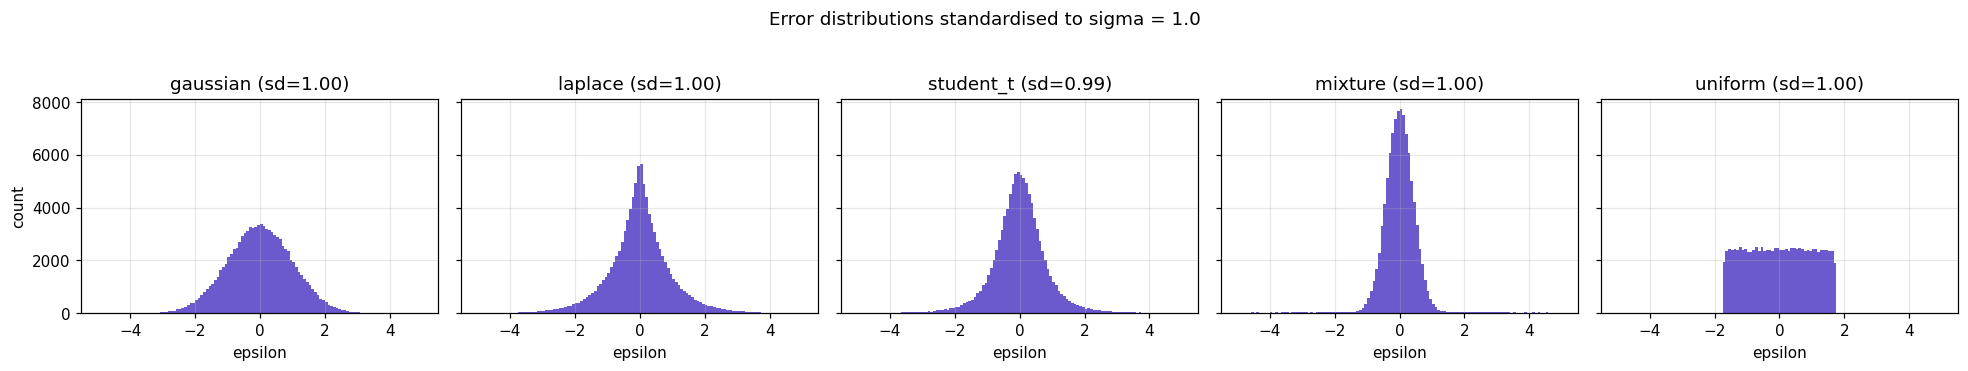

In [5]:
sigma_demo = 1.0
demo = {d: generate_error(d, sigma_demo, N, rng) for d in DIST_NAMES}
print("empirical sd at sigma = 1:", {d: round(float(v.std()), 4) for d, v in demo.items()})

fig, axes = plt.subplots(1, 5, figsize=(18, 3.2), sharey=True)
for ax, d in zip(axes, DIST_NAMES):
    ax.hist(demo[d], bins=120, range=(-5, 5), color="slateblue")
    ax.set(title=f"{d} (sd={demo[d].std():.2f})", xlabel="epsilon")
axes[0].set_ylabel("count")
fig.suptitle(f"Error distributions standardised to sigma = {sigma_demo}", y=1.04)
fig.tight_layout()
fig.savefig(FIG_DIR / "error_distributions.png", bbox_inches="tight")
plt.show()

## 8. Main Simulation

Every (distribution, $\sigma$) pair reuses the same base latent `z`; only $\epsilon$ is redrawn, and all
decoders see the identical $z$ and $\epsilon$. Full per-condition numbers go to `results/results.csv`;
the sections below show only compact slices.

In [6]:
records = [evaluate_condition(z, dist, sigma, rng, T_z)
           for dist in DIST_NAMES for sigma in SIGMAS]
results = pd.DataFrame(records)
results.to_csv(RESULTS_DIR / "results.csv", index=False)
print(f"{len(results)} conditions x {N} coordinates -> {RESULTS_DIR / 'results.csv'}")

75 conditions x 100000 coordinates -> results\results.csv


## 9. BER Results

BER for the three decoders at a representative noise level. Remember the denominators differ: `thr_ber`
is computed over the encoded subset only, so it is not directly comparable to the other two columns —
it answers "how often is a *retained* coordinate wrong", at the cost of discarding
$1 - 2\Phi(-\alpha_{\text{thr}})$ of the payload.

In [7]:
SNAPSHOT_SIGMA = 1.0
snap = results[np.isclose(results.sigma, SNAPSHOT_SIGMA)]
display(snap.set_index("distribution")[
    ["gs_ber", "rot_ber", "ber_diff", "thr_ber", "thr_skip_rate", "thr_n_encoded"]].round(4))
print(f"BER at sigma = {SNAPSHOT_SIGMA}; ber_diff is (rotation BER - GS BER); "
      f"thr_* use threshold alpha = {THR_ALPHA}.")

,gs_ber,rot_ber,ber_diff,thr_ber,thr_skip_rate,thr_n_encoded
distribution,,,,,,
gaussian,0.2488,0.2156,-0.0332,0.1517,0.3843,61569
laplace,0.2143,0.1655,-0.0488,0.1217,0.3843,61569
student_t,0.1964,0.1350,-0.0613,0.0989,0.3843,61569
mixture,0.1391,0.0514,-0.0877,0.0407,0.3843,61569
uniform,0.2802,0.2692,-0.0110,0.1853,0.3843,61569


BER at sigma = 1.0; ber_diff is (rotation BER - GS BER); thr_* use threshold alpha = 0.5.


## 10. Matched-Pairs Results

Where the sign-vs-rotation BER gap comes from, as percentages of coordinates at the same representative
$\sigma$. The threshold decoder is omitted here because it scores a different denominator. These are
paired outcome statistics, not claims about a "winner".

In [8]:
cols = ["both_correct", "gs_only_correct", "rot_only_correct", "both_wrong"]
pairs = 100 * snap.set_index("distribution")[cols] / N
pairs.columns = ["both correct", "GS only correct", "rotation only correct", "both wrong"]
print(f"% of coordinates at sigma = {SNAPSHOT_SIGMA}")
display(pairs.round(2))

% of coordinates at sigma = 1.0


,both correct,GS only correct,rotation only correct,both wrong
distribution,,,,
gaussian,70.50,4.62,7.95,16.93
laplace,75.23,3.34,8.22,13.21
student_t,77.36,3.00,9.14,10.50
mixture,84.87,1.22,9.99,3.92
uniform,66.15,5.83,6.93,21.09


## 11. Visualizations

### Plot 1 — BER vs. sigma (one figure per error distribution)

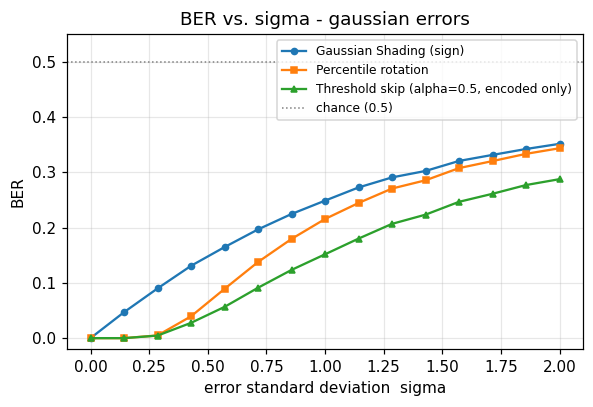

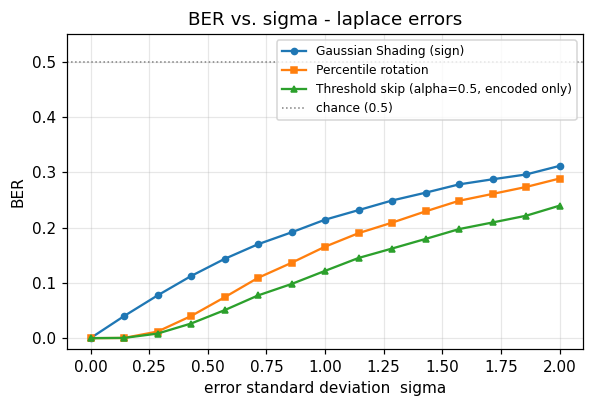

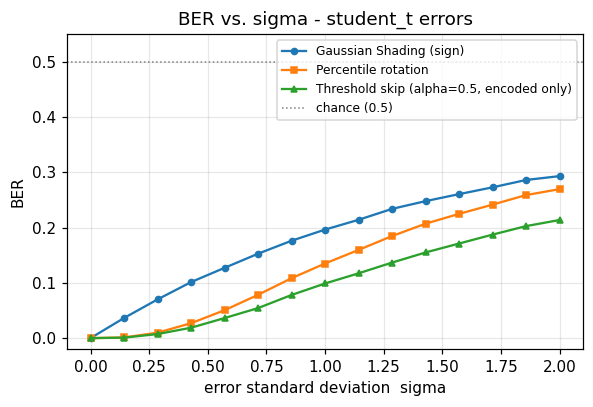

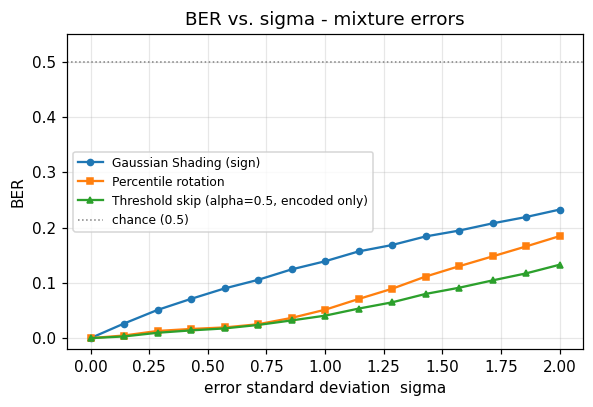

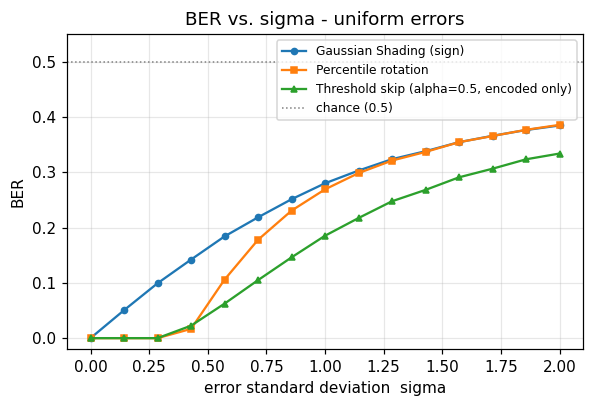

In [9]:
for dist in DIST_NAMES:
    sub = results[results.distribution == dist]
    fig, ax = plt.subplots(figsize=(5.5, 3.8))
    ax.plot(sub.sigma, sub.gs_ber, "o-", ms=4, label="Gaussian Shading (sign)")
    ax.plot(sub.sigma, sub.rot_ber, "s-", ms=4, label="Percentile rotation")
    ax.plot(sub.sigma, sub.thr_ber, "^-", ms=4,
            label=f"Threshold skip (alpha={THR_ALPHA}, encoded only)")
    ax.axhline(0.5, color="gray", ls=":", lw=1, label="chance (0.5)")
    ax.set(xlabel="error standard deviation  sigma", ylabel="BER",
           title=f"BER vs. sigma - {dist} errors", ylim=(-0.02, 0.55))
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"ber_vs_sigma_{dist}.png", bbox_inches="tight")
    plt.show()

### Plot 2 — BER difference (rotation $-$ Gaussian Shading)

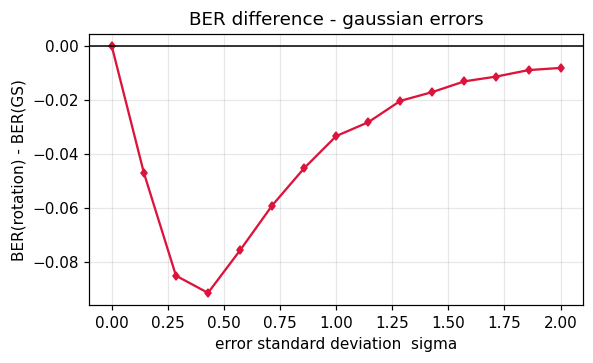

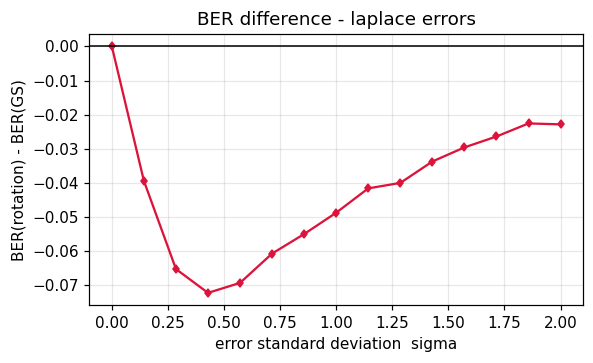

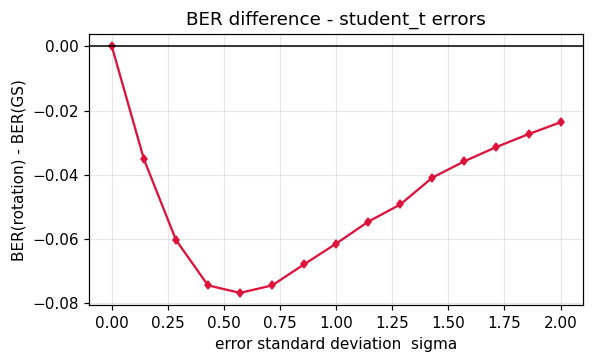

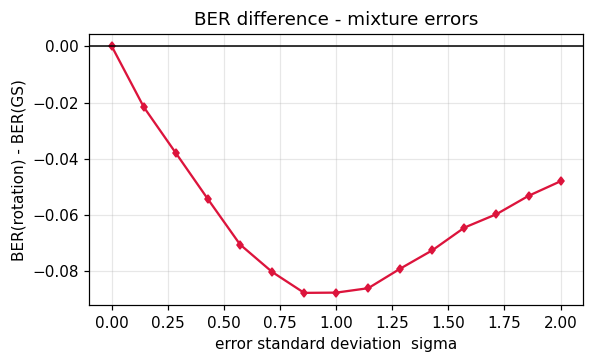

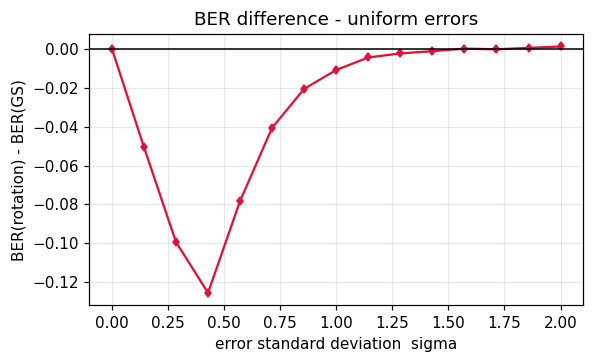

In [10]:
for dist in DIST_NAMES:
    sub = results[results.distribution == dist]
    fig, ax = plt.subplots(figsize=(5.5, 3.4))
    ax.plot(sub.sigma, sub.ber_diff, "d-", ms=4, color="crimson")
    ax.axhline(0, color="k", lw=1)
    ax.set(xlabel="error standard deviation  sigma",
           ylabel="BER(rotation) - BER(GS)", title=f"BER difference - {dist} errors")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"ber_diff_{dist}.png", bbox_inches="tight")
    plt.show()

### Plot 3 — Paired outcomes at representative noise levels

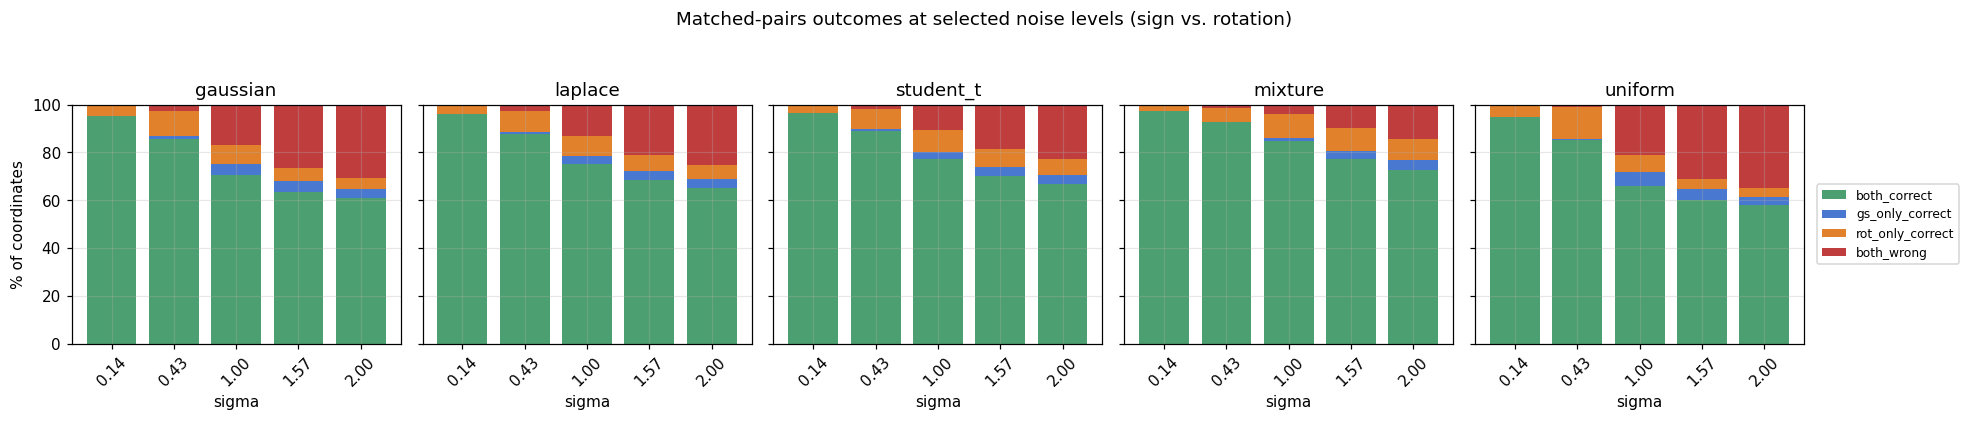

In [11]:
# A few representative sigmas rather than all 15, to keep the bars readable.
sel_sigmas = [SIGMAS[i] for i in (1, 3, 7, 11, 14)]
colors = ["#4c9f70", "#4878cf", "#e1812c", "#c03d3e"]

fig, axes = plt.subplots(1, 5, figsize=(18, 3.6), sharey=True)
for ax, dist in zip(axes, DIST_NAMES):
    sub = results[(results.distribution == dist) & (results.sigma.isin(sel_sigmas))]
    x, bottom = np.arange(len(sub)), np.zeros(len(sub))
    for col, color in zip(cols, colors):
        vals = 100 * sub[col].to_numpy() / N
        ax.bar(x, vals, bottom=bottom, color=color, label=col)
        bottom += vals
    ax.set_xticks(x, [f"{s:.2f}" for s in sub.sigma], rotation=45)
    ax.set(title=dist, xlabel="sigma")
axes[0].set_ylabel("% of coordinates")
axes[-1].legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.suptitle("Matched-pairs outcomes at selected noise levels (sign vs. rotation)", y=1.05)
fig.tight_layout()
fig.savefig(FIG_DIR / "paired_outcomes.png", bbox_inches="tight")
plt.show()

### Plot 4 — Threshold trade-off

Raising $\alpha_{\text{thr}}$ discards more coordinates but keeps only the high-magnitude ones, which
need a larger perturbation to flip sign. This shows both sides of that trade at one representative
noise level.

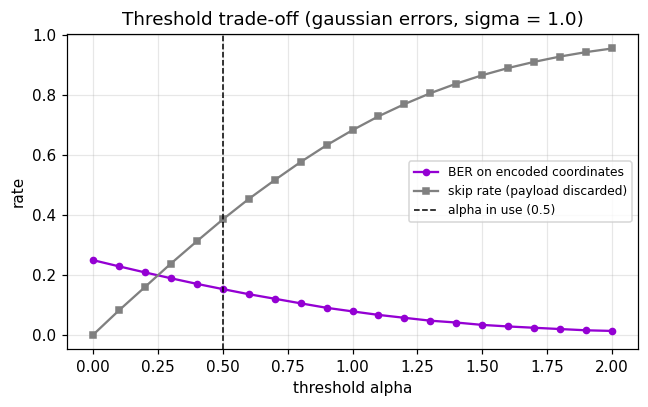

In [12]:
alphas = np.linspace(0.0, 2.0, 21)
eps_demo = generate_error("gaussian", SNAPSHOT_SIGMA, N, rng)
z_hat_demo = z + eps_demo
trade = pd.DataFrame([threshold_stats(*decode_threshold(z, z_hat_demo, a), N) for a in alphas],
                     index=alphas)

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(alphas, trade.thr_ber, "o-", ms=4, color="darkviolet", label="BER on encoded coordinates")
ax.plot(alphas, trade.thr_skip_rate, "s-", ms=4, color="grey", label="skip rate (payload discarded)")
ax.axvline(THR_ALPHA, color="k", ls="--", lw=1, label=f"alpha in use ({THR_ALPHA})")
ax.set(xlabel="threshold alpha", ylabel="rate",
       title=f"Threshold trade-off (gaussian errors, sigma = {SNAPSHOT_SIGMA})")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "threshold_tradeoff.png", bbox_inches="tight")
plt.show()

## 12. Example Individual Decoding Decisions

Ten randomly chosen coordinates from a single condition. `thr_skipped` marks coordinates the threshold
decoder discards; those can never be `thr_wrong`.

In [13]:
ex_dist, ex_sigma = "gaussian", 1.0
ex_eps = generate_error(ex_dist, ex_sigma, N, rng)
ex_hat = z + ex_eps
idx = rng.choice(N, size=10, replace=False)
ex_encoded, ex_thr_err = decode_threshold(z[idx], ex_hat[idx])

examples = pd.DataFrame({
    "z": z[idx], "epsilon": ex_eps[idx], "z_hat": ex_hat[idx], "T(z)": T_z[idx],
    "dist_to_z": np.abs(ex_hat[idx] - z[idx]),
    "dist_to_Tz": np.abs(ex_hat[idx] - T_z[idx]),
    "gs_wrong": decode_gaussian_shading(z[idx], ex_hat[idx]),
    "rot_wrong": decode_rotation(z[idx], ex_hat[idx], T_z[idx]),
    "thr_skipped": ~ex_encoded,
    "thr_wrong": ex_thr_err,
})
display(examples.round(3))
print(f"condition: {ex_dist} errors, sigma = {ex_sigma}, threshold alpha = {THR_ALPHA}")

,z,epsilon,z_hat,T(z),dist_to_z,dist_to_Tz,gs_wrong,rot_wrong,thr_skipped,thr_wrong
0,-0.478,-1.216,-1.694,0.901,1.216,2.596,False,False,True,False
1,-0.115,-2.035,-2.151,1.685,2.035,3.836,False,False,True,False
2,1.590,0.852,2.442,-0.140,0.852,2.583,False,False,False,False
3,1.223,0.081,1.303,-0.281,0.081,1.585,False,False,False,False
4,0.455,-0.674,-0.220,-0.934,0.674,0.714,True,False,True,False
5,1.133,-1.436,-0.303,-0.328,1.436,0.025,True,True,False,True
6,-0.826,0.258,-0.568,0.537,0.258,1.105,False,False,False,False
7,0.228,-0.940,-0.712,-1.340,0.940,0.628,True,True,True,False
8,1.118,-0.244,0.875,-0.336,0.244,1.211,False,False,False,False
9,1.378,-0.519,0.858,-0.212,0.519,1.071,False,False,False,False


condition: gaussian errors, sigma = 1.0, threshold alpha = 0.5


## 13. Verification

In [14]:
big_alpha = 100.0   # nothing is encoded at this threshold
enc_big, err_big = decode_threshold(z, z + 1.0, big_alpha)
gs_on_encoded = decode_gaussian_shading(z, z + generate_error("gaussian", 1.0, N,
                                                              np.random.default_rng(SEED)))

checks = {
    "zero-noise BER is 0 for all decoders": sum(zero_noise_errors.values()) == 0,
    "BERs match raw error counts": (
        np.allclose(results.gs_ber, results.gs_errors / N)
        and np.allclose(results.rot_ber, results.rot_errors / N)
        and np.allclose(results.thr_ber, results.thr_errors / results.thr_n_encoded)
    ),
    "every 2x2 matrix sums to N": (results[cols].sum(axis=1) == N).all(),
    "skipped + encoded = N in every condition": (
        (results.thr_n_skipped + results.thr_n_encoded == N).all()
        and np.allclose(results.thr_skip_rate + results.thr_encoded_rate, 1.0)
    ),
    "threshold errors only occur on encoded coordinates": (results.thr_errors <= results.gs_errors).all(),
    # P(|z| < alpha) = 1 - 2*Phi(-alpha); the encoded rate is the complement, 2*Phi(-alpha).
    "skip rate matches 1 - 2*Phi(-alpha)": abs(
        results.thr_skip_rate.iloc[0] - (1 - 2 * stats.norm.cdf(-THR_ALPHA))) < 0.01,
    "empty encoded set gives NaN, not 0": np.isnan(threshold_stats(enc_big, err_big, N)["thr_ber"]),
    "threshold BER equals sign BER restricted to encoded subset": np.isclose(
        threshold_stats(*decode_threshold(z, z + generate_error(
            "gaussian", 1.0, N, np.random.default_rng(SEED))), N)["thr_ber"],
        gs_on_encoded[ENCODED].mean()),
    "T(z) contains no inf/nan": np.all(np.isfinite(T_z)),
    "relative column is NaN exactly when GS BER is 0": (
        (results.rel_ber_change.isna() == (results.gs_ber == 0)).all()
    ),
    "rotation tie-break decodes as bit 0": not decode_rotation(
        np.array([1.0]), np.array([(1.0 + rotate_latent(np.array([1.0]))[0]) / 2]))[0],
    "|z| == alpha is encoded, not skipped": decode_threshold(
        np.array([THR_ALPHA]), np.array([THR_ALPHA]))[0][0],
    "z_hat exactly 0 counts as non-negative": not decode_gaussian_shading(
        np.array([0.5]), np.array([0.0]))[0],
}
emp_sd = {d: generate_error(d, 1.0, 200_000, np.random.default_rng(SEED)).std() for d in DIST_NAMES}
checks["all five error models have sd ~ sigma"] = all(abs(s - 1.0) < 0.05 for s in emp_sd.values())

for name, ok in checks.items():
    print(f"[{'PASS' if bool(ok) else 'FAIL'}] {name}")
assert all(bool(v) for v in checks.values()), "a verification check failed"

[PASS] zero-noise BER is 0 for all decoders
[PASS] BERs match raw error counts
[PASS] every 2x2 matrix sums to N
[PASS] skipped + encoded = N in every condition
[PASS] threshold errors only occur on encoded coordinates
[PASS] skip rate matches 1 - 2*Phi(-alpha)
[PASS] empty encoded set gives NaN, not 0
[PASS] threshold BER equals sign BER restricted to encoded subset
[PASS] T(z) contains no inf/nan
[PASS] relative column is NaN exactly when GS BER is 0
[PASS] rotation tie-break decodes as bit 0
[PASS] |z| == alpha is encoded, not skipped
[PASS] z_hat exactly 0 counts as non-negative
[PASS] all five error models have sd ~ sigma


## 14. Summary of Results

In [15]:
final = results.groupby("distribution")[["gs_ber", "rot_ber", "thr_ber"]].mean().round(4)
final.columns = ["Gaussian Shading", "rotation", f"threshold (alpha={THR_ALPHA}, encoded only)"]
print("Mean BER across the whole sigma sweep, by error distribution:")
display(final)
final.to_csv(RESULTS_DIR / "summary_table.csv")

Mean BER across the whole sigma sweep, by error distribution:


,Gaussian Shading,rotation,"threshold (alpha=0.5, encoded only)"
distribution,,,
gaussian,0.2210,0.1848,0.1425
laplace,0.1910,0.1491,0.1158
mixture,0.1314,0.0711,0.0523
student_t,0.1779,0.1304,0.0986
uniform,0.2449,0.2160,0.1673


**What was simulated.** Standard normal latents ($N = 100{,}000$, seed 42) perturbed as
$\hat z = z + \epsilon$, with all decoding rules applied to the identical $z$ and $\epsilon$. No
encoding, generation, or inversion step is involved.

**Error channels.** Gaussian, Laplace, Student-t ($\nu = 3$), a 5%/95% Gaussian mixture with scale ratio
$1{:}10$, and Uniform — each standardised to the requested $\sigma$ and swept over $\sigma \in [0,2]$ at
15 levels.

**BER vs. noise.** Every decoder is exact at $\sigma = 0$ and rises toward chance as $\sigma$ grows,
slowly: the Gaussian-channel sign-flip probability is $\arctan(\sigma)/\pi$, only $\approx 0.35$ at
$\sigma = 2$, so the top of the sweep is the substantial-error regime rather than a saturated one.
Widen `SIGMAS` to reach saturation.

**Paired outcomes.** The 2×2 tables decompose the sign-vs-rotation BER gap into coordinates only one
rule got right; the four cells sum to $N$ in every condition.

**Threshold decoding.** Skipping $|z| < \alpha_{\text{thr}}$ removes exactly the coordinates whose sign
is easiest to flip, so the BER over retained coordinates falls as $\alpha_{\text{thr}}$ rises — but the
skip rate $1 - 2\Phi(-\alpha_{\text{thr}})$ is payload thrown away, so its BER is not comparable to
the full-denominator rules. Skip status is read off the pre-noise $z$ by design.

**Rotation geometry.** $D(z) = |T(z) - z|$ diverges at the median, bottoms out at $\approx 1.349$ at the
quartiles, and grows like $|z|$ in the tails.

These statements describe the specified synthetic latent-space error channels only. Whether those
channels resemble real diffusion inversion error is a separate question, for the TABA experiment.